## Laboratuvar: Keras ile İleri Düzey Veri Artırma 


Bu laboratuvarda, Keras kullanarak çeşitli veri artırma tekniklerini uygulamayı ve denemeyi öğreneceksiniz. 

#### Öğrenim hedefleri 

Bu laboratuvarın sonunda şunları yapabileceksiniz: 

- Keras kullanarak çeşitli veri artırma tekniklerini uygulayabileceksiniz. 
- Veri kümesinde özellik bazında ve örnek bazında normalizasyon uygulayabileceksiniz. 
- Görüntülere rastgele gürültü ekleyen özel bir artırma fonksiyonu tanımlayıp uygulayabileceksiniz. 
- Artırılmış görüntüleri görüntüleyerek farklı artırma tekniklerinin etkisini anlayabileceksiniz.  


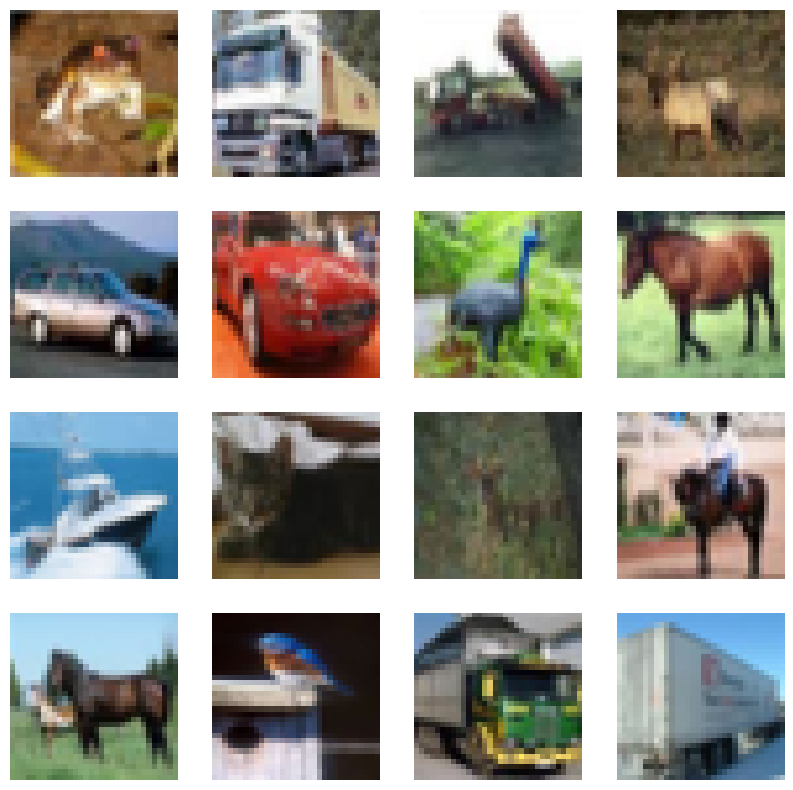

In [10]:
# Install required libraries
!pip install tensorflow==2.16.2 matplotlib==3.9.1 scipy

# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset for training images
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values for augmentation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Display a sample of the training images
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()


### **Create sample.jpg for the Lab**


In [11]:
from PIL import Image, ImageDraw  # PIL kütüphanesinden Image ve ImageDraw modüllerini import ediyoruz. Görüntü oluşturma ve çizim yapmak için gerekli.

# Create a blank white image
image = Image.new('RGB', (224, 224), color = (255, 255, 255))  
# Yeni bir resim oluşturuyoruz:
# 'RGB' → renk modu (kırmızı, yeşil, mavi)
# (224, 224) → resmin boyutu (genişlik x yükseklik) piksel cinsinden
# color=(255, 255, 255) → tüm resmi beyaz renkle dolduruyoruz (255,255,255 = beyaz)

# Draw a red square
draw = ImageDraw.Draw(image)  
# Resim üzerine çizim yapabilmek için bir "çizim nesnesi" oluşturuyoruz.

draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))  
# Kırmızı bir kare çiziyoruz:
# [(50, 50), (174, 174)] → kareyi tanımlayan köşe koordinatları (sol üst ve sağ alt)
# fill=(255, 0, 0) → kareyi kırmızı ile doldur (RGB kırmızı = 255,0,0)

# Save the image
image.save('sample.jpg')  
# Oluşturduğumuz resmi 'sample.jpg' adıyla kaydediyoruz.

In [12]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array 
# Gerekli kütüphaneleri import ediyoruz:
# numpy → sayısal işlemler, dizi (array) işlemleri
# matplotlib → görüntüleri göstermek için
# tensorflow.keras.preprocessing.image → görüntüleri yüklemek ve ön işleme yapmak için

# Load a sample image 
img_path = 'sample.jpg'  
# Önceden oluşturduğun kırmızı kareli resmi seçiyoruz

img = load_img(img_path)  
# Resmi yüklüyoruz → PIL Image objesi olarak

x = img_to_array(img)  
# Yüklenen resmi NumPy dizisine çeviriyoruz → (height, width, channels) şeklinde
# Yani resim artık matematiksel bir array olarak işlendi

x = np.expand_dims(x, axis=0)  
# Model için boyutları değiştiriyoruz → (1, height, width, channels)  
# Bu “batch dimension” ekliyor. Yani artık tek bir resim ama model bunu bir batch gibi görecek

Kodda: 
- `!pip install tensorflow==2.16.2 matplotlib==3.9.1` komutu, belirtilen sürümlerdeki `TensorFlow ve Matplotlib` kütüphanelerini yükler.  

- `tensorflow`, Python'da makine öğrenimi için kullanılan ana kütüphanedir.  

- `Model`, Functional API ile bir model oluşturmak için kullanılır. 

- `Input` ve ‘Dense’, modelinizde kullanacağınız katman türleridir.  


#### 2. Adım: Temel veri genişletme 

ImageDataGenerator'ı kullanarak döndürme, genişlik kaydırma, yükseklik kaydırma, eğme, yakınlaştırma ve yatay çevirme gibi temel genişletme işlemlerini aşağıdaki gibi uygulayın:


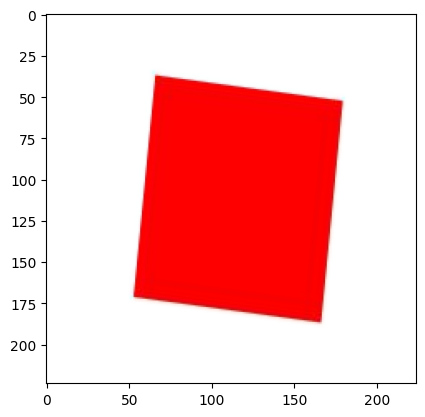

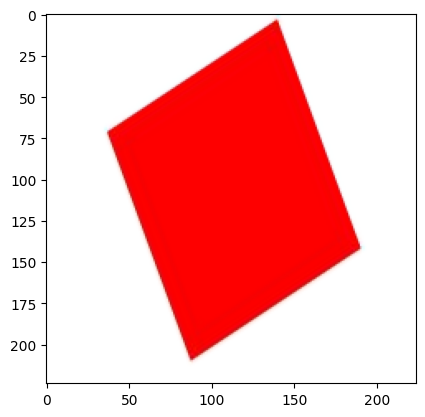

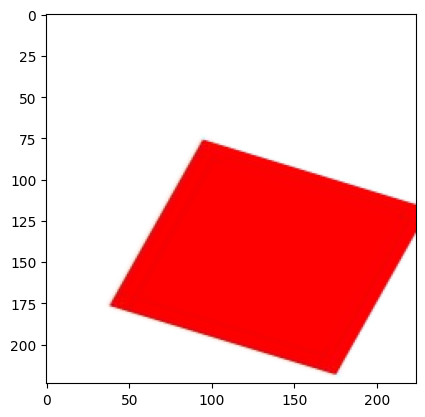

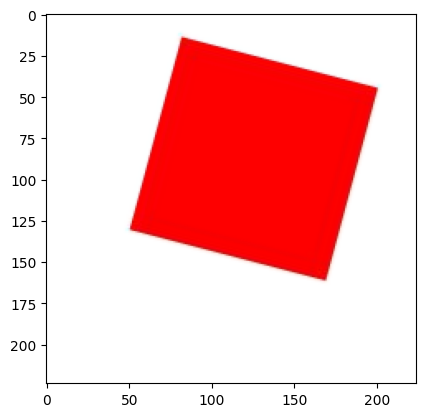

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
# Gerekli kütüphaneler: NumPy, Matplotlib ve Keras image preprocessing

# Load the sample image
img_path = 'sample.jpg'           # Önceden oluşturduğun kırmızı kareli resmi seç
img = load_img(img_path)           # Resmi yükle (PIL Image objesi)
x = img_to_array(img)              # Resmi NumPy dizisine çevir
x = np.expand_dims(x, axis=0)      # Batch boyutu ekle → (1, height, width, channels)

# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,             # Rastgele döndürme ±40 derece
    width_shift_range=0.2,         # Yatay kaydırma ± %20
    height_shift_range=0.2,        # Dikey kaydırma ± %20
    shear_range=0.2,               # Eğme (shear) uygulama
    zoom_range=0.2,                # Yakınlaştırma ± %20
    horizontal_flip=True,          # Yatay çevirme (flip)
    fill_mode='nearest'            # Boş alanları en yakın pikselle doldur
)

# Generate batches of augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):  # 1 resimlik batchler üret
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))  # Üretilen resmi göster
    i += 1
    if i % 4 == 0:                                 # 4 resim üretilince dur
        break

plt.show()  # Tüm üretilen resimleri ekranda göster


#### 3. Adım: Özellik bazında ve örnek bazında normalleştirme 

Veri kümesinde özellik bazında ve örnek bazında normalleştirmeyi aşağıdaki şekilde uygulayın:    


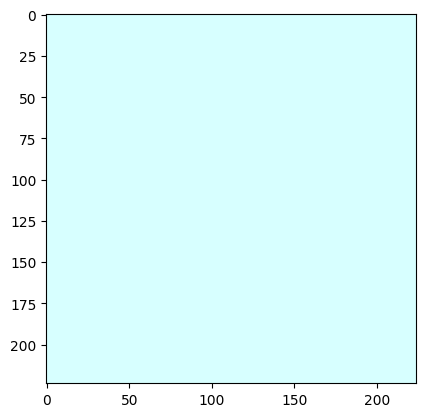

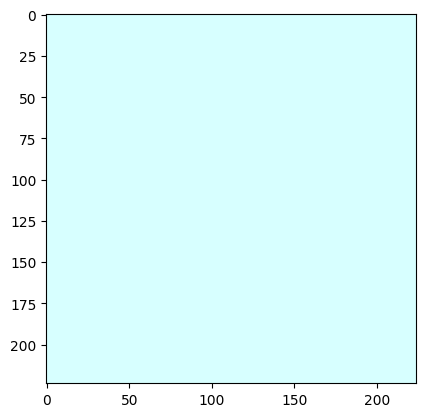

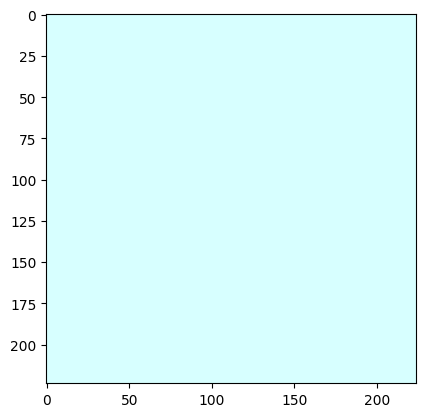

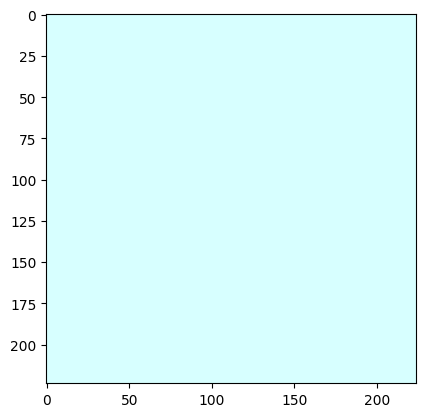

In [14]:
# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,            # Tüm veri seti için ortalamayı sıfırla (mean subtraction)
    featurewise_std_normalization=True, # Tüm veri seti için standart sapmaya böl (variance scaling)
    samplewise_center=True,             # Her örnek için ortalamayı sıfırla
    samplewise_std_normalization=True   # Her örnek için standart sapmaya böl
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)  # Generator'u resme “uyarlıyoruz” → featurewise işlemleri için ortalama ve std hesaplıyor

# Generate batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):  # 1 resimlik batchler üret
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))  # Normalize edilmiş resmi göster
    i += 1
    if i % 4 == 0:                                # 4 resim gösterince döngüyü kır
        break

plt.show()  # Tüm üretilen resimleri ekranda göster



#### 4. Adım: Özel veri artırma işlevi 

Ardından, görüntülere rastgele gürültü ekleyen özel bir artırma işlevini aşağıdaki gibi tanımlayıp uygularsınız: 


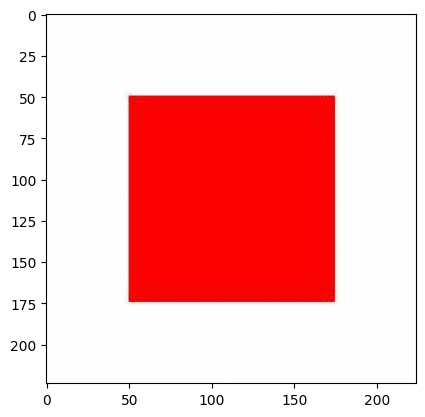

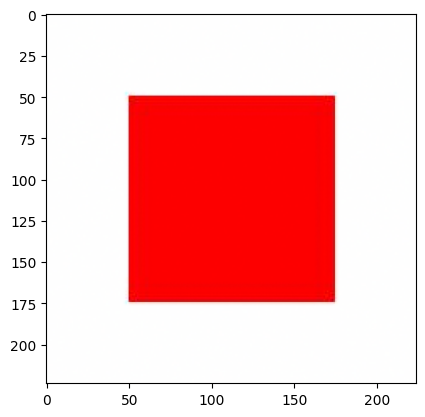

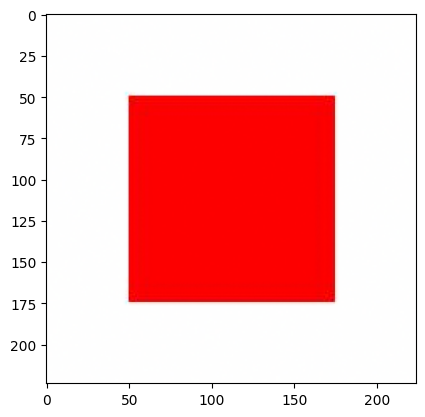

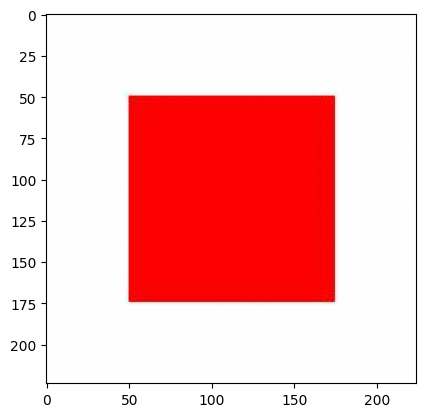

In [15]:
# Define a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)  # Her piksel için ortalaması 0, std 0.1 olan rastgele gürültü üret
    return image + noise                             # Orijinal resme gürültüyü ekle

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)
# ImageDataGenerator'a özel bir fonksiyon veriyoruz → her resim işlendiğinde bu fonksiyon çalışacak

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):  # 1 resimlik batchler üret
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))  # Gürültü eklenmiş resmi göster
    i += 1
    if i % 4 == 0:                                # 4 resim üretilince dur
        break

plt.show()  # Tüm üretilen resimleri ekranda göster

#### 5. Adım: Artırılmış görüntüleri görüntüleyin

Her bir artırma tekniğinin etkisini anlamak için artırılmış görüntüleri görüntüleyin. 


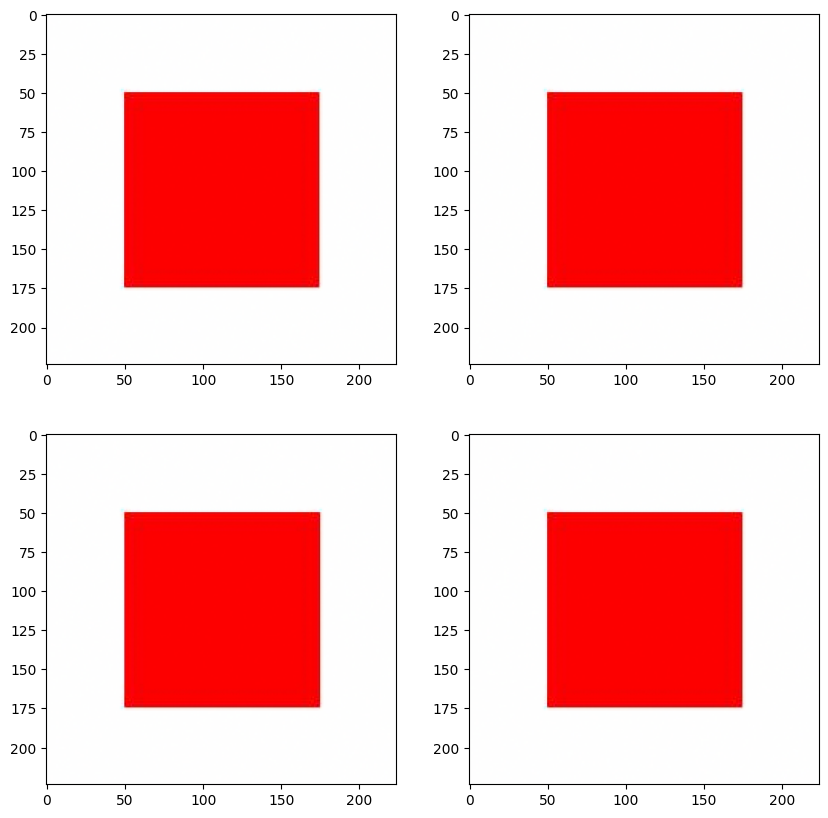

In [16]:
# Visualizing multiple augmented versions of the same image
plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4:  # Show only 4 versions
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()



Bu Markdown açıklaması, Jupyter Notebook'ta netlik sağlayarak kodun ve amacının daha kolay anlaşılmasını sağlayacaktır.


## Practice Exercises:


### Alıştırma 1: Farklı Genişletme Tekniklerini Uygulama ve Görselleştirme 

  

Amaç: Farklı genişletme tekniklerini denemek ve bunların etkilerini görselleştirmek. 


Bu alıştırma için kullanılacak resimlerden oluşan `sample_images` klasörünü indirin.


In [17]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip

--2026-03-24 19:09:32--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 14868 (15K) [application/zip]
Saving to: ‘sample-images.zip’

sample-images.zip   100%[===================>]  14.52K  --.-KB/s    in 0s      

2026-03-24 19:09:32 (29.7 MB/s) - ‘sample-images.zip’ saved [14868/14868]



Klasörü açarak resimleri çıkarın


In [18]:
!unzip sample-images.zip 

Archive:  sample-images.zip
   creating: sample_images/
  inflating: sample_images/training_images1.jpg  
  inflating: sample_images/training_images2.jpg  
  inflating: sample_images/training_images3.jpg  


### Talimatlar: 

1. Dönme, genişlik kaydırma, yükseklik kaydırma, eğme, yakınlaştırma ve yatay çevirme gibi çeşitli görüntü işleme tekniklerini kullanarak bir `ImageDataGenerator` örneği oluşturun. 

2. İşlenmiş görüntüleri oluşturun ve görüntüleyin. 


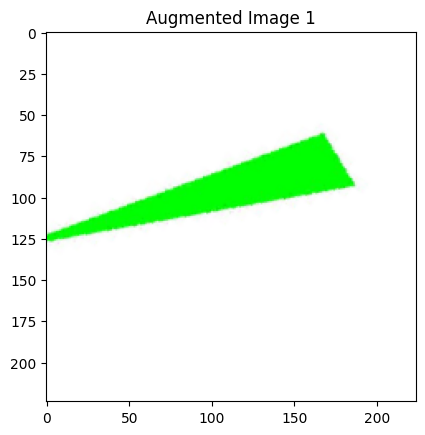

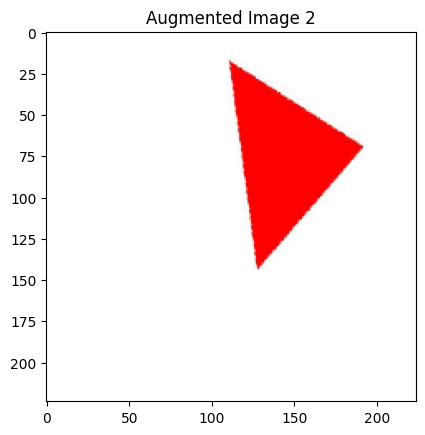

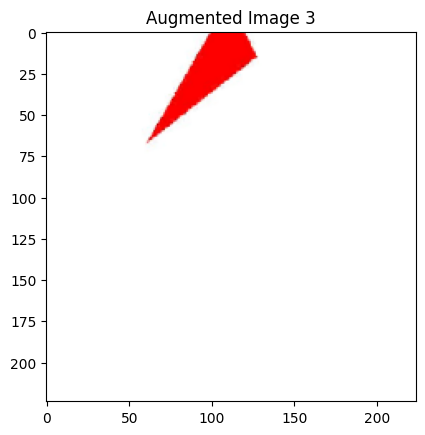

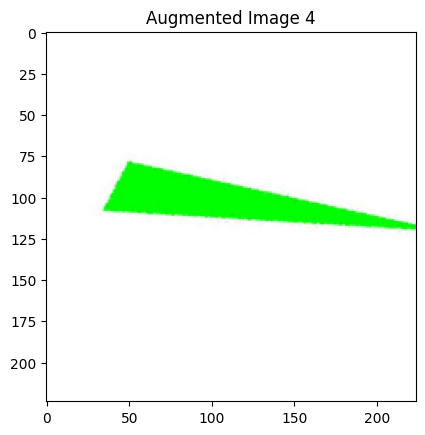

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img  

import matplotlib.pyplot as plt  

import numpy as np  
  

datagen = ImageDataGenerator(  

    rotation_range=40,  

    width_shift_range=0.2,  

    height_shift_range=0.2,  

    shear_range=0.2,  

    zoom_range=0.2,  

    horizontal_flip=True,  

    fill_mode='nearest'  

)  


# Load and preprocess the dataset  

image_paths = [  

    'sample_images/training_images1.jpg',  

    'sample_images/training_images2.jpg',  

    'sample_images/training_images3.jpg'  

]  


training_images = []  

for image_path in image_paths:  

    img = load_img(image_path, target_size=(224, 224))  

    img_array = img_to_array(img)  

    training_images.append(img_array)  

training_images = np.array(training_images)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Augmented Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  


<details>
    <summary>Click here for Solution</summary>

```python

 

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img  

import matplotlib.pyplot as plt  

import numpy as np  

 

# Define the augmentation parameters  

datagen = ImageDataGenerator(  

    rotation_range=40,  

    width_shift_range=0.2,  

    height_shift_range=0.2,  

    shear_range=0.2,  

    zoom_range=0.2,  

    horizontal_flip=True,  

    fill_mode='nearest'  

)  

 

# Load and preprocess the dataset  

image_paths = [  

    'sample_images/training_images1.jpg',  

    'sample_images/training_images2.jpg',  

    'sample_images/training_images3.jpg'  

]  

 

training_images = []  

for image_path in image_paths:  

    img = load_img(image_path, target_size=(224, 224))  

    img_array = img_to_array(img)  

    training_images.append(img_array)  

training_images = np.array(training_images)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Augmented Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

 ```   

</details>


### Alıştırma 2: Özellik Bazlı ve Örnek Bazlı Normalleştirme Uygulama
 
Amaç: Veri kümesine özellik bazlı ve örnek bazlı normalleştirme uygulamak.
 
Talimatlar:
1. Özellik bazlı ve örnek bazlı normalleştirme özelliklerine sahip bir `ImageDataGenerator` örneği oluşturun.
2. `ImageDataGenerator`'ı veri kümesine uyarlayın ve normalleştirilmiş görüntüleri görselleştirin.


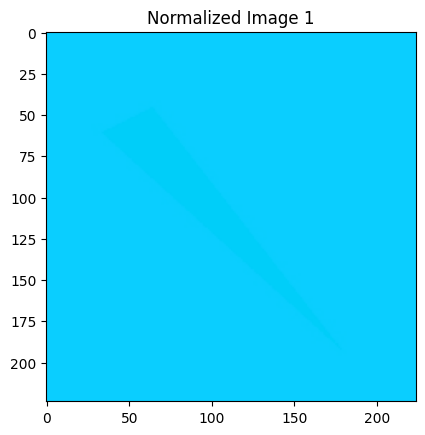

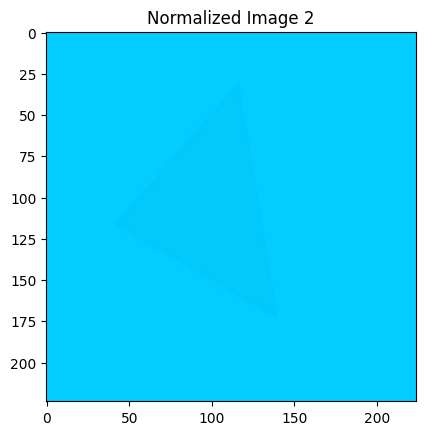

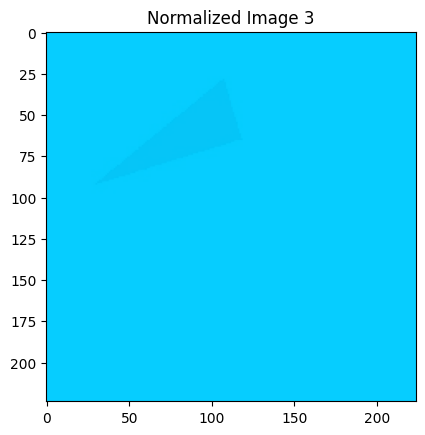

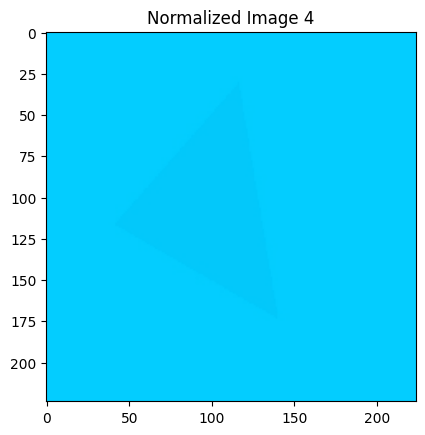

In [20]:
# Create an instance of ImageDataGenerator with normalization options  

datagen = ImageDataGenerator(  

    featurewise_center=True,  

    featurewise_std_normalization=True,  

    samplewise_center=True,  

    samplewise_std_normalization=True  

)  

 

# Fit the ImageDataGenerator to the dataset  

datagen.fit(training_images)  

 

# Generate and visualize normalized images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Normalized Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

<details>
    <summary>Click here for Solution</summary>

```python
 

# Create an instance of ImageDataGenerator with normalization options  

datagen = ImageDataGenerator(  

    featurewise_center=True,  

    featurewise_std_normalization=True,  

    samplewise_center=True,  

    samplewise_std_normalization=True  

)  

 

# Fit the ImageDataGenerator to the dataset  

datagen.fit(training_images)  

 

# Generate and visualize normalized images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Normalized Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

 

 ```   

</details>

  


### Alıştırma 3: Özel Bir Veri Artırma İşlevi Oluşturma ve Uygulama
 
Amaç: Görüntülere rastgele gürültü ekleyen özel bir veri artırma işlevi tanımlayın ve bunu uygulayın.
 
Talimatlar:
1. Bir görüntüye rastgele gürültü ekleyen bir işlev tanımlayın.
2. Özel artırma işlevini kullanarak bir `ImageDataGenerator` örneği oluşturun.
3. Artırılmış görüntüleri oluşturun ve görselleştirin.


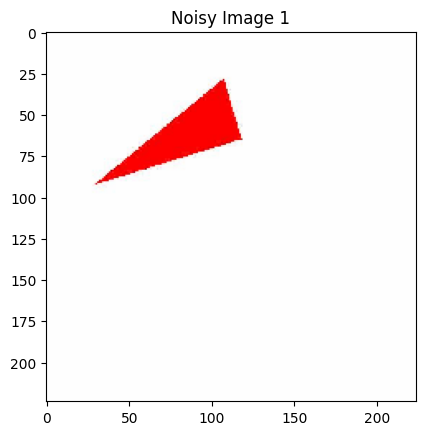

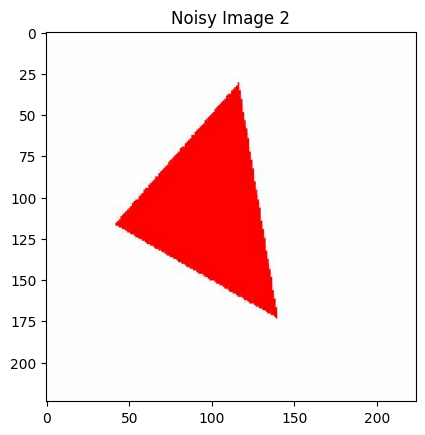

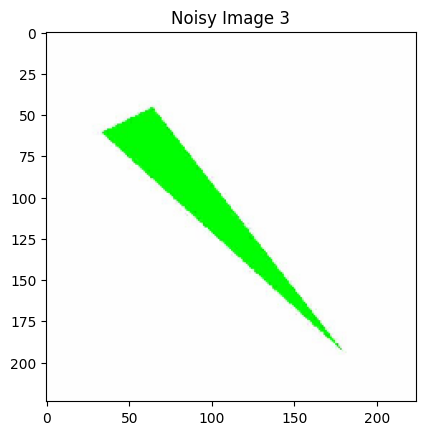

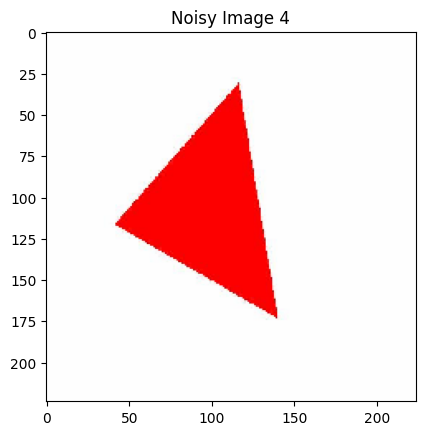

In [21]:
# Define a custom augmentation function to add random noise 
def add_random_noise(image):  

    noise = np.random.normal(0, 0.1, image.shape)  

    return image + noise  

 

# Create an instance of ImageDataGenerator with custom augmentation  

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Noisy Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  